## Introduction

In this section, we study and implement a **Logarithmic Number System (LNS)** as an alternative to **Fixed-Point** and **Floating-Point** number systems. In this representation, numbers are stored as the logarithm of their absolute value, which is represented in fixed-point form, together with the sign of the number. This representation allows multiplication and division over real numbers to be performed using simple addition and subtraction, respectively. One of the main challenges of this system is addition and subtraction, which are usually approximated using techniques such as **LUT** or **Bit-Shift**.

Numbers in the LNS domain are represented as:

$$
\tilde{X} = (z_x, s_x, m_x)
$$

where $z_x$ indicates whether the number is zero, and $s_x$ represents the sign of the number. The value zero cannot be represented in LNS as $b^m$, so an extra bit is usually used to represent zero. Also, $m_x$ (the logarithm of the absolute value) is a two’s-complement fixed-point number with $W$ bits, of which $f$ bits are fractional.

In this section, we first implement software functions to convert numbers from the real domain to LNS and back, and then write functions for multiplication and addition (with different approximations). We also analyze results such as absolute and relative error in the logarithmic domain for different parameters, including the LNS bit width, the number of fractional bits, and the chosen base.

---


### 1.1 Conversion from Real Domain to LNS and Vice Versa
First, implement the necessary functions for converting numbers from the real domain to LNS and back. The LNS format should follow the description above. The base of the logarithm, bit length, and number of fractional bits must be given as inputs to these functions together with the number, so that the conversion is performed correctly.

To verify these functions, by setting the base to 2 and the bit width to 6 (3 bits for the fractional part), first determine the range of positive real numbers that can be represented by this LNS system. Then, in a table, report the LNS representation of the following numbers, their corresponding values in the real domain after converting back from logarithmic representation, and the absolute and relative errors in the real domain. Finally, analyze the results.

$$
\text{Test numbers} = \{0.0, 1.0, 1.5, 0.25, -2.0, 12.0, 15, -7.5, 0.001\}
$$
---


In [19]:
import numpy as np
class UnderflowError(Exception):
    pass

class LNSNum:
    def __init__(self, b=2, W=8, f=4, z=0, s=0, m=0):
        
        if b <= 0 or b == 1:
            raise ValueError("base must be positive and not equal to 1")

        self.b = b   # logarithm base
        self.W = W   # width - precission
        self.f = f   # fraction point position
        self.z = z   # zero flag
        self.s = s   # sign bit
        self.m = m   # log magnitude
    
    def __repr__(self):
        return f"LNS(z={self.z}, s={self.s}, m={self.m:^5})"


def to_lns(x, base=2, W=8, f=4) -> LNSNum:
          
    z = 0        
    s = 0        
    m = 0        
        
    if isinstance(x, (int, float, np.integer, np.floating)):
        if x == 0:
            z = 1
            return LNSNum(base, W, f, z, s, m)
        
        s = 1 if x < 0 else 0
        abs_x = abs(x)
        
        try:
            log_val = np.log(abs_x) / np.log(base)
            
            # check overflow/underflow base on traction point position
            scale = 2**f
            max_val = 2**(W - f - 1) - 2**(-f)
            min_val = -2**(W - f - 1)
        
            if log_val > max_val:
                raise OverflowError(f"Value {x} too large, return the max value")
                
            if log_val < min_val:
                raise UnderflowError(f"Value {x} too small, return zero")
                
                      
            # Quantize log_val to fixed-point format with f fractional bits
            # so m is stored in steps of 1/(2^f)
            m = int(np.round(log_val * scale)) / scale
        
        except OverflowError as e:
            m = max_val
            print(f"WARNING: {str(e)}")
            return LNSNum(base, W, f, z, s, m)
        
        except UnderflowError as e:
            z = 1
            print(f"WARNING: {str(e)}")           
            return LNSNum(base, W, f, z, s, m)
                    
    else :
        raise TypeError("input type sould be int or float")
    
    return LNSNum(base, W, f, z, s, m)

    
def to_real(lns_num : LNSNum) -> float:
    if lns_num.z:
        return 0
    sign = -1 if lns_num.s else 1
    return sign * (lns_num.b ** lns_num.m)

In [21]:
print(f"Basis: {base}, Width: {W}, Fraction bits: {f}")

min = base ** (-2**(W - f - 1))
max = base ** (2**(W - f - 1) - 2**(-f))
print(f"Representable magnitude range: [{min:.4f}, {max:.4f}]")


Basis: 2, Width: 6, Fraction bits: 3
Representable magnitude range: [0.0625, 14.6721]


In [20]:
test_numbers = [0.0, 1.0, 1.5, 0.25, -2.0, 12.0, 15, -7.5, 0.001]
base, W, f = 2, 6, 3

print("\nNumber\tLNS Representation\t\tReconstructed\t\tError\t\tError (%)")

for num in test_numbers:
    lns = to_lns(num, base, W, f)
    real = to_real(lns)
    error = abs(num - real)
    rel_error = (error / abs(num)) * 100 if num != 0 else 0

    print(f"{num}\t{lns}\t\t{real:.4f}\t\t\t{error:.4f}\t\t{rel_error:.4f}")



Number	LNS Representation		Reconstructed		Error		Error (%)
0.0	LNS(z=1, s=0, m=  0  )		0.0000			0.0000		0.0000
1.0	LNS(z=0, s=0, m= 0.0 )		1.0000			0.0000		0.0000
1.5	LNS(z=0, s=0, m=0.625)		1.5422			0.0422		2.8141
0.25	LNS(z=0, s=0, m=-2.0 )		0.2500			0.0000		0.0000
-2.0	LNS(z=0, s=1, m= 1.0 )		-2.0000			0.0000		0.0000
12.0	LNS(z=0, s=0, m=3.625)		12.3377			0.3377		2.8141
15	LNS(z=0, s=0, m=3.875)		14.6721			0.3279		2.1862
-7.5	LNS(z=0, s=1, m=2.875)		-7.3360			0.1640		2.1862
0.001	LNS(z=1, s=0, m=  0  )		0.0000			0.0010		100.0000



---

### 1.2 Error Analysis in Number Conversion
In this section, we aim to examine more closely the error caused by converting numbers from the real domain to the logarithmic domain, and study the effect of parameters such as bit width and base on this error.

For this purpose, for each of the following parameter sets, determine the range of positive real numbers that can be represented by the corresponding LNS system. Then select a sufficient number of numbers uniformly across this range and plot the absolute and relative errors in separate graphs. Also report the average of these errors.

Then, by comparing the representable range of each of the following 4 parameter sets, the chosen base, the number of bits used ($W$), and the average relative errors, analyze the results and explain the observed tradeoffs.

$$
(\text{base}, W, f) = \{(\sqrt{2}, 8, 4), (2, 7, 4), (4, 6, 4), (16, 5, 4)\}
$$

---


In [44]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(441)

parameters_set = [
    (np.sqrt(2), 8, 4),
    (2, 7, 4),
    (4, 6, 4),
    (16, 5, 4)
]

results = {}

for base, W, f in parameters_set:
    
    print(f"\nParameters: base={base:.3f}, W={W}, f={f}")
    print(f"Range: [{min_val:.6f}, {max_val:.6f}]")

    min_val = base ** (-2**(W - f - 1))
    max_val = base ** (2**(W - f - 1) - 2**(-f))

    num_samples = 1000
    real_samples = np.random.uniform(min_val, max_val, num_samples)

    errors = []
    rel_errors = []

    for x in real_samples:
        lns = to_lns(x, base, W, f)
        real = to_real(lns)

        error = abs(x - real)
        rel_error = (error / abs(x)) * 100 if x != 0 else 0

        errors.append(error)
        rel_errors.append(rel_error)

    mean_error = np.mean(errors)
    mean_rel_error = np.mean(rel_errors)

    results[(base, W, f)] = {
        'samples': real_samples,
        'errors': errors,
        'rel_errors': rel_errors,
        'mean_error': mean_error,
        'mean_rel_error': mean_rel_error,
        'range': (min_val, max_val)
    }

    print(f"Mean Error: {mean_error:.6f}")
    print(f"Mean Relative Error: {mean_rel_error:.6f}%")



Parameters: base=1.414, W=8, f=4
Range: [0.062500, 13.454343]
Mean Error: 0.045000
Mean Relative Error: 0.556266%

Parameters: base=2.000, W=7, f=4
Range: [0.062500, 15.657153]
Mean Error: 0.082967
Mean Relative Error: 1.088852%

Parameters: base=4.000, W=6, f=4
Range: [0.062500, 15.321652]
Mean Error: 0.167035
Mean Relative Error: 2.163827%

Parameters: base=16.000, W=5, f=4
Range: [0.062500, 14.672065]
Mean Error: 0.292534
Mean Relative Error: 4.289251%


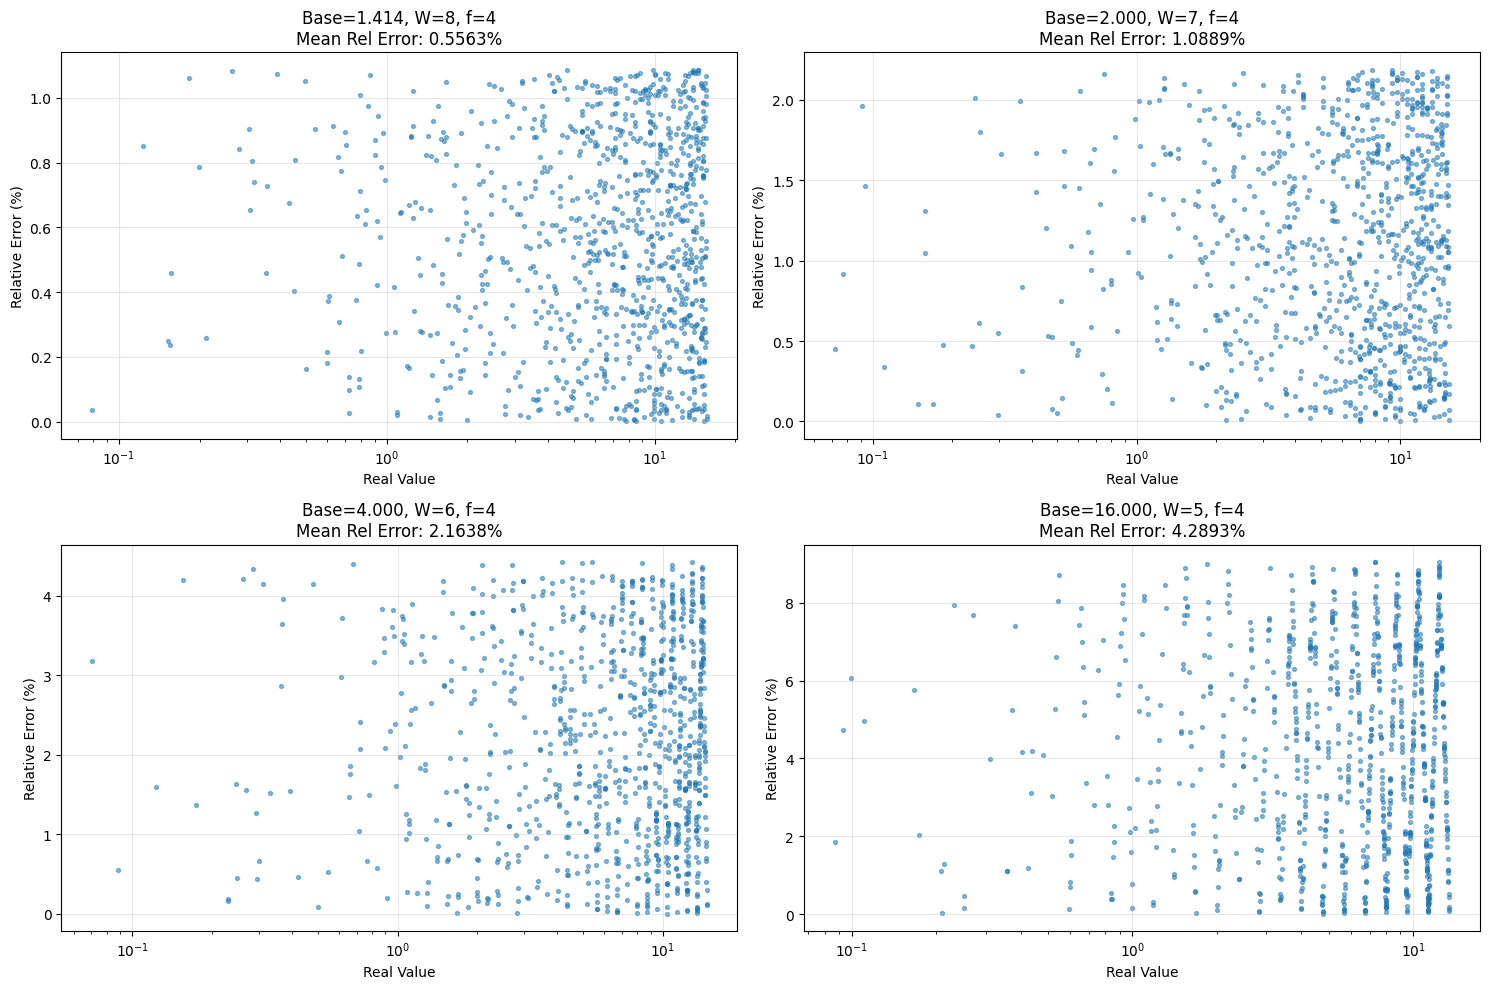

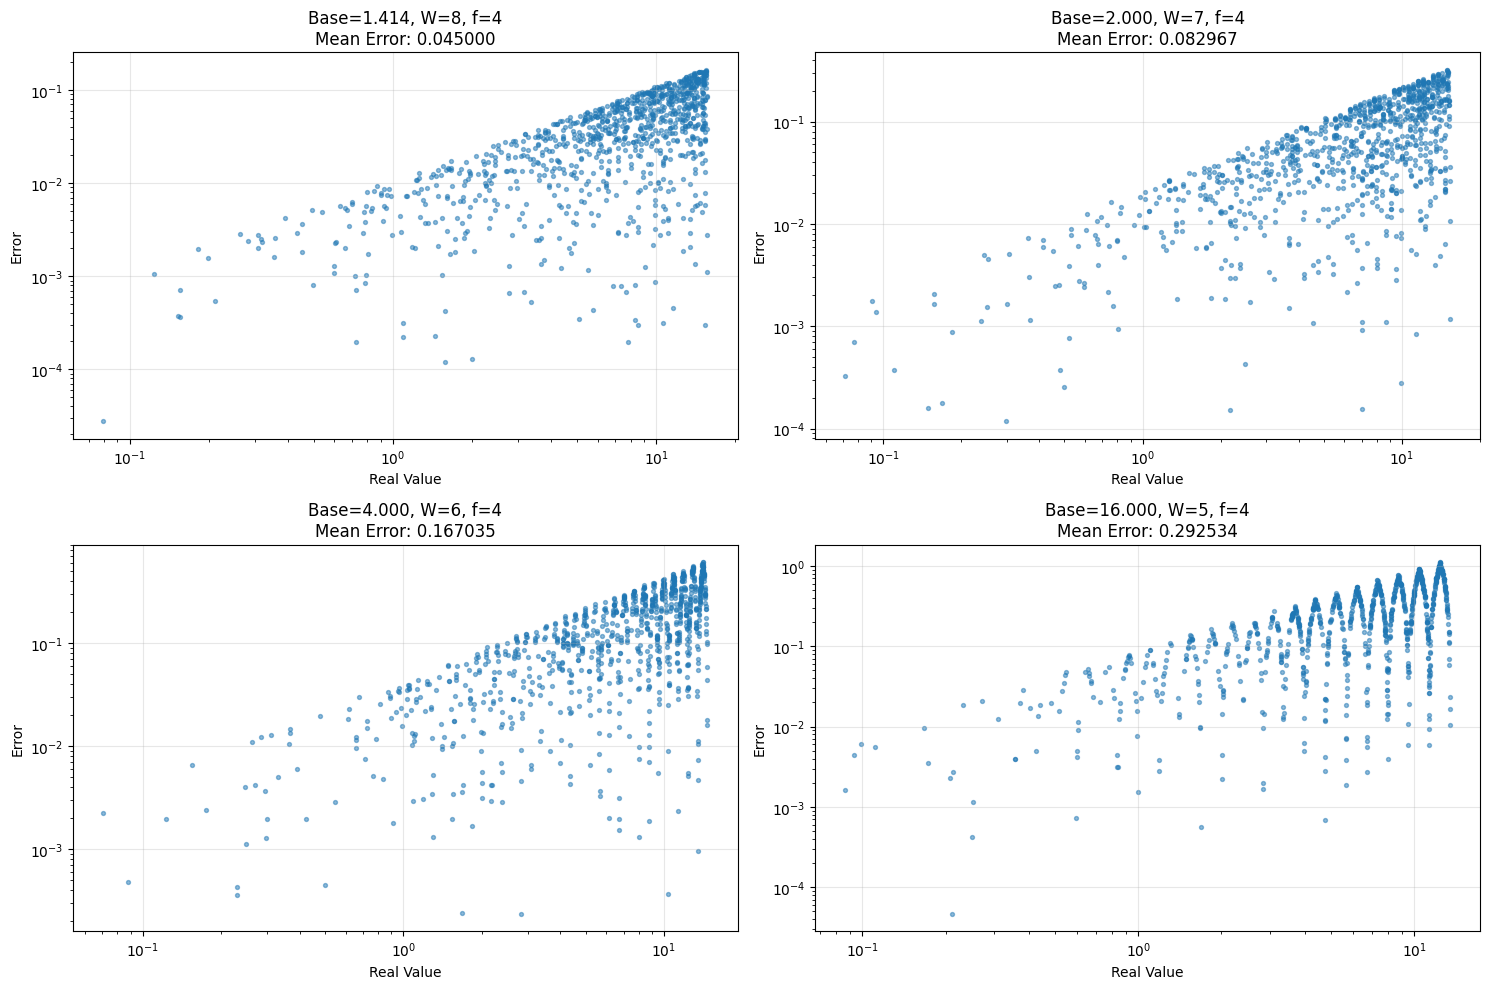

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ((base, W, f), data) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(data['samples'], data['rel_errors'], alpha=0.5, s=8)
    ax.set_xlabel('Real Value')
    ax.set_ylabel('Relative Error (%)')
    ax.set_title(f'Base={base:.3f}, W={W}, f={f}\nMean Rel Error: {data["mean_rel_error"]:.4f}%')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ((base, W, f), data) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(data['samples'], data['errors'], alpha=0.5, s=8)
    ax.set_xlabel('Real Value')
    ax.set_ylabel('Error')
    ax.set_title(f'Base={base:.3f}, W={W}, f={f}\nMean Error: {data['mean_error']:.6f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
